# How the Heat Model Works, in Pictures

This notebook has no equations to follow and nothing to fit. It is the conceptual model behind
`pipetransport.heat` in plain English, with two cross-sections through the ground.

The pictures are not sketches. Every isotherm below is computed from the same steady solution the
package's kernel is built on, so what you see is what the model believes.

## The idea in four sentences

1. Water in a buried pipe drifts toward the temperature of the ground around it. How fast depends
   on how thick the pipe is, what it is made of, and how well the soil conducts.
2. The ground is not a fixed backdrop. A pipe that has been giving off heat has warmed the soil
   around it, and afterwards it is exchanging against that warmed halo instead of against
   undisturbed ground.
3. That halo takes weeks to build and weeks to fade, so the temperature at the tap depends on what
   the network was doing long before today.
4. The surface matters because the ground can dump heat there. Heat leaving a pipe spreads
   outward, and the part of it that reaches the surface leaves the system.

In [1]:
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np


class Pipe(NamedTuple):
    """One pipe in a cross-section: where it sits, how big it is, how hard it exchanges."""

    x0: float
    depth: float
    radius: float
    strength: float
    label: str


from pipetransport import plot

## The trick that makes the surface work: a mirror image

A buried pipe losing heat into an infinite block of soil would warm it forever. Real ground has a
surface, and the surface sheds heat to the air, which keeps the halo from growing without bound.

The model handles this the way groundwater models handle a river boundary: with a **mirror
image**. Place an imaginary pipe the same distance *above* the surface as the real one is below,
and make it a *sink* of exactly the strength the real one is a source. Their fields cancel exactly
on the surface line, which is what "the surface holds its own temperature" means. Below ground the
sum of the two is the real answer.

The mirror sits at the *effective* depth, slightly deeper than the real pipe, because a surface
that is only a good heat exchanger rather than a perfect one behaves like a perfect one buried a
little further down.

In [2]:
def conduction_arrows(ax, xx, zz, field, *, step, mask_within=0.0, centres=()):
    """Draw the conduction direction: unit arrows straight down the temperature gradient.

    Only the direction is drawn. The magnitude spans orders of magnitude between the pipe wall
    and the far field, so any single arrow scale would show one and hide the other.
    """
    gz, gx = np.gradient(np.nan_to_num(field), zz[:, 0], xx[0])
    ux, uz = -gx, -gz
    norm = np.hypot(ux, uz)
    with np.errstate(invalid="ignore", divide="ignore"):
        ux, uz = ux / norm, uz / norm
    keep = np.isfinite(ux) & (zz < -0.05)
    for cx, cz, radius in centres:
        keep &= np.hypot(xx - cx, zz - cz) > max(mask_within, radius * 1.6)
    ux, uz = np.where(keep, ux, np.nan), np.where(keep, uz, np.nan)
    ax.quiver(
        xx[::step, ::step],
        zz[::step, ::step],
        ux[::step, ::step],
        uz[::step, ::step],
        color="0.15",
        alpha=0.85,
        width=0.004,
        scale=30,
        pivot="mid",
    )


def buried_field(x, z, *, depth, radius, strength=1.0):
    """Steady temperature rise around a buried line source with its mirror image.

    The real source sits at ``z = -depth`` and its mirror sink at ``z = +depth``; on the surface
    (``z = 0``) their contributions cancel exactly. This is the shape factor the package's steady
    soil resistance ``ln(2 d / r) / (2 pi kappa)`` comes from.
    """
    to_source = np.hypot(x, z + depth)
    to_image = np.hypot(x, z - depth)
    return strength * np.log(np.maximum(to_image, 1e-9) / np.maximum(to_source, radius))

## Cross-section 1: looking along the pipe

The flow is *into the screen*: this is what you would see standing in a trench looking down the
pipe. The pipe is the circle; the ground surface is the line at the top.

- **Solid contours are isotherms** — lines of equal temperature in the soil, like contours of
  equal head on a groundwater map.
- **Arrows are the direction heat conducts**, always straight across the isotherms from warm to
  cold, like flow lines crossing head contours at right angles.

The pipe here is *warmer* than the ground, so heat leaves it.

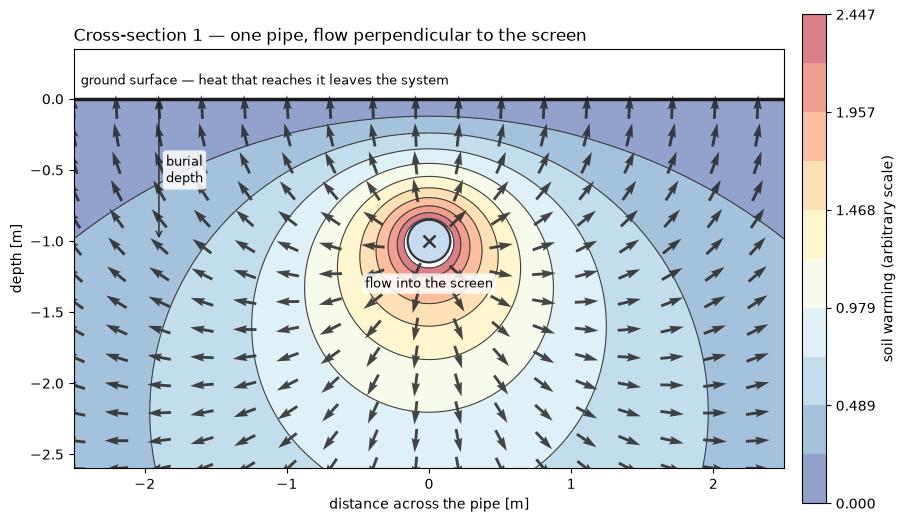

In [3]:
depth, radius = 1.0, 0.15
x = np.linspace(-2.5, 2.5, 400)
z = np.linspace(-2.6, 0.0, 320)
xx, zz = np.meshgrid(x, z)
field = buried_field(xx, zz, depth=depth, radius=radius)
field[np.hypot(xx, zz + depth) < radius] = np.nan  # inside the pipe there is water, not soil

fig, ax = plt.subplots(figsize=(9.5, 5.4))
levels = np.linspace(0.0, np.nanmax(field) * 0.92, 11)
shading = ax.contourf(xx, zz, field, levels=levels, cmap="RdYlBu_r", alpha=0.55)
ax.contour(xx, zz, field, levels=levels, colors="0.25", linewidths=0.8)
conduction_arrows(ax, xx, zz, field, step=24, centres=[(0.0, -depth, radius)])

ax.add_patch(plt.Circle((0.0, -depth), radius, facecolor="#c6dbef", edgecolor="0.2", lw=1.6, zorder=5))
ax.plot(0.0, -depth, marker="x", ms=8, mew=1.8, color="0.2", zorder=6)
ax.text(
    0.0,
    -depth - radius - 0.1,
    "flow into the screen",
    fontsize=9,
    ha="center",
    va="top",
    zorder=6,
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.85},
)
ax.axhline(0.0, color="0.1", lw=2.5)
ax.text(-2.45, 0.08, "ground surface — heat that reaches it leaves the system", fontsize=9, va="bottom")
ax.annotate("", xy=(-1.9, 0.0), xytext=(-1.9, -depth), arrowprops={"arrowstyle": "<->", "color": "0.15"})
ax.text(
    -1.85,
    -depth / 2,
    "burial\ndepth",
    fontsize=9,
    va="center",
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.85},
)
fig.colorbar(shading, ax=ax, pad=0.02, label="soil warming (arbitrary scale)")
ax.set_xlabel("distance across the pipe [m]")
ax.set_ylabel("depth [m]")
ax.set_title("Cross-section 1 — one pipe, flow perpendicular to the screen", loc="left")
ax.set_aspect("equal")
ax.set_ylim(-2.6, 0.35)
fig.tight_layout()

Three things to read off this picture.

**The isotherms crowd near the pipe.** Almost the whole temperature drop happens in the first
few pipe diameters of soil. That is why the soil dominates the resistance for a small pipe: the
heat has to squeeze out through a thin shell before it has any room.

**The arrows fan upward.** Heat does not spread evenly in all directions — the surface is a sink,
so more of it goes up than down. The deeper the pipe, the less this matters and the better the
soil insulates.

**Isotherms meet the surface at right angles to it.** That is the mirror image doing its job: the
surface is held at its own temperature, so no isotherm can cross it.

### What the model keeps and what it throws away

The package does not solve this field at run time. It only needs one number out of it — how much
the soil resists heat leaving the pipe — plus how that number *grows over time* while the halo is
still developing. Everything else in the picture is summarised into those two.

## Cross-section 2: two pipes in series, seen from the side

Now the flow is *left to right along the screen*: an upstream pipe and the downstream pipe it
feeds, with different properties. The upstream one is wider, deeper and under grass; the
downstream one is thinner, shallower and under pavement, which is both warmer at the surface and
a better conductor.

Same reading as before: solid contours are isotherms, arrows point the way heat conducts.

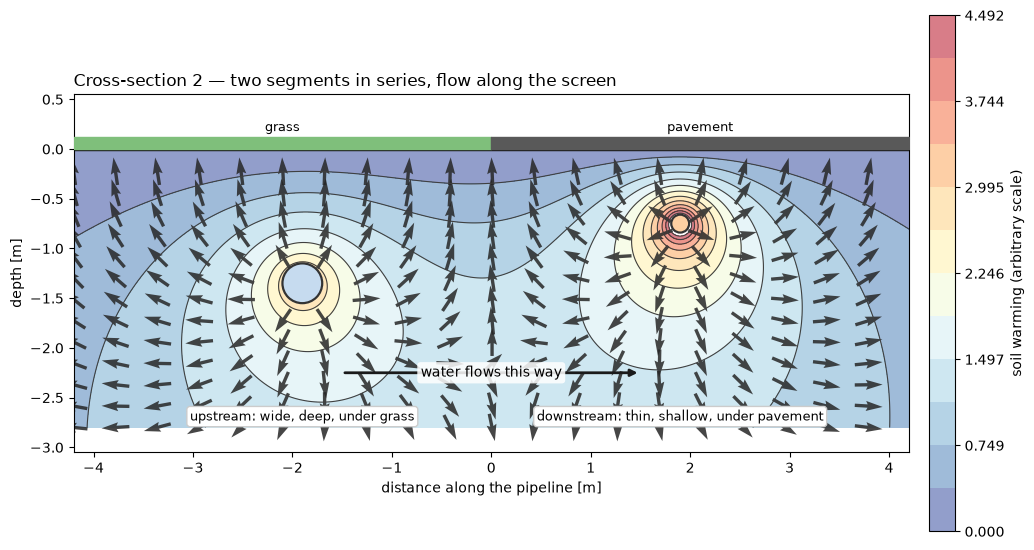

In [4]:
up = Pipe(x0=-1.9, depth=1.35, radius=0.20, strength=1.0, label="upstream: wide, deep, under grass")
down = Pipe(x0=1.9, depth=0.75, radius=0.09, strength=1.7, label="downstream: thin, shallow, under pavement")

x = np.linspace(-4.2, 4.2, 520)
z = np.linspace(-2.8, 0.0, 340)
xx, zz = np.meshgrid(x, z)
field = sum(
    buried_field(xx - pipe.x0, zz, depth=pipe.depth, radius=pipe.radius, strength=pipe.strength) for pipe in (up, down)
)
for pipe in (up, down):
    field[np.hypot(xx - pipe.x0, zz + pipe.depth) < pipe.radius] = np.nan

fig, ax = plt.subplots(figsize=(11, 5.6))
levels = np.linspace(0.0, np.nanmax(field) * 0.9, 13)
shading = ax.contourf(xx, zz, field, levels=levels, cmap="RdYlBu_r", alpha=0.55)
ax.contour(xx, zz, field, levels=levels, colors="0.25", linewidths=0.8)
conduction_arrows(
    ax,
    xx,
    zz,
    field,
    step=26,
    centres=[(pipe.x0, -pipe.depth, pipe.radius) for pipe in (up, down)],
)

for pipe, face in zip((up, down), ("#c6dbef", "#fdd0a2"), strict=True):
    ax.add_patch(plt.Circle((pipe.x0, -pipe.depth), pipe.radius, facecolor=face, edgecolor="0.2", lw=1.6, zorder=5))
    ax.text(
        pipe.x0,
        -2.62,
        pipe.label,
        fontsize=9,
        ha="center",
        va="top",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.8"},
    )
fig.colorbar(shading, ax=ax, pad=0.02, label="soil warming (arbitrary scale)")

ax.axhline(0.0, color="0.1", lw=2.5)
ax.fill_between([-4.2, 0.0], 0.0, 0.12, color="#7fbf7b", zorder=4)
ax.fill_between([0.0, 4.2], 0.0, 0.12, color="0.35", zorder=4)
ax.text(-2.1, 0.18, "grass", fontsize=9, ha="center")
ax.text(2.1, 0.18, "pavement", fontsize=9, ha="center")
ax.annotate(
    "",
    xy=(1.5, -2.25),
    xytext=(-1.5, -2.25),
    arrowprops={"arrowstyle": "-|>", "color": "0.1", "lw": 2.0},
)
ax.text(
    0.0,
    -2.25,
    "water flows this way",
    fontsize=10,
    ha="center",
    va="center",
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "none", "alpha": 0.85},
)
ax.set_xlabel("distance along the pipeline [m]")
ax.set_ylabel("depth [m]")
ax.set_title("Cross-section 2 — two segments in series, flow along the screen", loc="left")
ax.set_aspect("equal")
ax.set_ylim(-3.05, 0.55)
fig.tight_layout()

The two halos have different shapes, and that is the point of splitting a pipeline into segments
at all. The shallow, thin, well-conducting downstream pipe exchanges far harder than the deep wide
one: its isotherms are tighter, its arrows are longer, and much more of its heat reaches the
surface. The same water passes through both, so it picks up one behaviour and then the other.

Notice also that the two halos **overlap** in the middle. The package does *not* model that: each
segment carries its own soil memory as if its neighbours were not there. It is a stated
assumption, and it is the main reason to keep segments from being far shorter than they are deep.

## What happens to the water, in words

Follow one parcel from the plant to a tap.

1. **It enters a pipe.** From that moment it starts drifting toward the temperature of the ground
   around that pipe — quickly in a thin pipe, slowly in a wide one.
2. **It gives up (or takes on) heat as it goes.** That heat does not vanish; it goes into the soil
   shell around that particular pipe, and stays in the model's books.
3. **It passes into the next pipe**, which may be shallower, thinner, or under a warmer surface.
   It starts drifting toward a different target, from wherever the last pipe left it.
4. **It arrives at the tap**, having been part-way to several different ground temperatures.

Meanwhile, and much more slowly:

5. **The soil remembers.** Every pipe's shell holds the heat that has been put into it, decaying
   away over weeks. Tomorrow's water meets today's leftovers.

## The one thing that is easy to get wrong

When does a pipe give up its heat?

The tempting answer is "when the water comes out" — count the temperature drop between the ends
and book it to the moment of delivery. That is wrong in a way that only shows up when water sits
still. A branch that draws nothing overnight is exchanging heat all night; if the whole night is
charged to the few minutes of the morning flush, that instant looks vastly more energetic than
anything real, and the model can end up delivering temperatures nothing in the inputs could
produce.

The package books the heat **over the hours it actually happens in**, by tracking how much heat
each pipe is holding, bin by bin. A pipe with no flow still loses heat, exactly as it does in the
ground. That is the difference between a model that settles down when you describe a pipe in finer
pieces and one that drifts further away.

## What the model does not claim

- **One memory per pipe.** The real halo is thicker where the water is hottest, near the inlet.
  The model gives the whole pipe one shell. Split a long pipe into pieces if that matters.
- **Neighbours ignored.** Two pipes in one trench warm each other; here they do not.
- **The ground is uniform under each cover.** No stones, no water table, no seasonal moisture.
- **The surface is a good exchanger, not a perfect one**, and the weather over it is something you
  supply — the model will not guess it.

Each of these is stated with numbers in the user guide's *Assumptions* page, and
`02_Network_Temperature.ipynb` puts the whole thing to work on a real network.

In [5]:
print("Both figures were computed from the package's own steady kernel:")
print("  a buried line source plus its mirror image, which is where")
print("  R_soil = ln(2 d / r) / (2 pi kappa) comes from.")
print()
for label, d, r in (("100 mm service line at 1.0 m", 1.0, 0.05), ("400 mm main at 1.2 m", 1.2, 0.20)):
    print(f"  {label:30s} shape factor ln(2d/r) = {np.log(2 * d / r):.2f}")
print()
print(f"colour palette shared with the rest of the package: {plot.series_colors(3)}")

Both figures were computed from the package's own steady kernel:
  a buried line source plus its mirror image, which is where
  R_soil = ln(2 d / r) / (2 pi kappa) comes from.

  100 mm service line at 1.0 m   shape factor ln(2d/r) = 3.69
  400 mm main at 1.2 m           shape factor ln(2d/r) = 2.48

colour palette shared with the rest of the package: ['#2a78d6', '#eb6834', '#1baf7a']
